<a href="https://colab.research.google.com/github/DioctonJM/DSP/blob/main/LAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

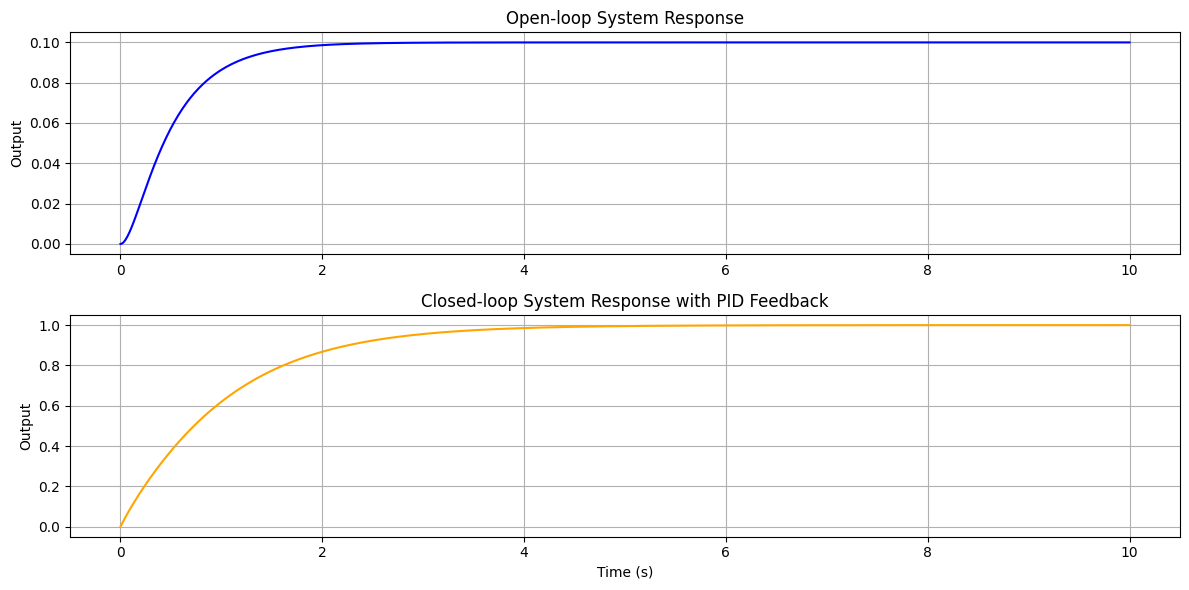

Steady-state error (Open-loop): 0.9001
Steady-state error (Closed-loop): 0.0000
Error Reduction: 50.00%


In [3]:
# Install control library (run once if needed)
!pip install control

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# Time vector
t = np.linspace(0, 10, 1000)

# DC Motor transfer function: 1 / (s^2 + 2s + 1)
num_motor = [2]
den_motor = [1, 11, 20.02]
G_motor = ctrl.TransferFunction(num_motor, den_motor)

# Open-loop response
t_ol, y_ol = ctrl.step_response(G_motor, t)

# PID Controller values (from your schematic setup)
Kp = 5
Ki = 10
Kd = 0.5

# PID Transfer Function: (Kd*s^2 + Kp*s + Ki)/s
PID = ctrl.TransferFunction([Kd, Kp, Ki], [1, 0])

# Closed-loop system with feedback: PID * Plant, unity feedback
open_loop = PID * G_motor
closed_loop = ctrl.feedback(open_loop, 1)

# Closed-loop response
t_cl, y_cl = ctrl.step_response(closed_loop, t)

# Steady-state error calculations
desired_value = 1.0
ss_error_open = abs(desired_value - y_ol[-1])
ss_error_closed = abs(desired_value - y_cl[-1])

# Plotting results
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_ol, y_ol, label="Open-loop", color="blue")
plt.title("Open-loop System Response")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_cl, y_cl, label="Closed-loop", color="orange")
plt.title("Closed-loop System Response with PID Feedback")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid(True)

plt.tight_layout()
plt.show()

# Print errors and percentage reduction
print(f"Steady-state error (Open-loop): {ss_error_open:.4f}")
print(f"Steady-state error (Closed-loop): {ss_error_closed:.4f}")

if ss_error_open > 0:
    reduction = ((ss_error_open - ss_error_closed) / ss_error_open) * 50
    print(f"Error Reduction: {reduction:.2f}%")
else:
    print("Open-loop error is zero or too small to calculate reduction.")
